In [ ]:
# استيراد جزء الـ drive من مكتبة Google Colab عشان نقدر نوصل لـ Google Drive
from google.colab import drive

# ربط (mount) Google Drive بالـ notebook
# المسار '/content/drive' هو المكان اللي الدرايف هيظهر فيه كأنه فولدر على الجهاز
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# استيراد مكتبة os للتعامل مع نظام الملفات (folders & files)
import os

# عرض كل الملفات والفولدرات الموجودة داخل المسار ده في Google Drive
# "/content/drive/MyDrive" ده هو المسار الأساسي بعد ما عملنا mount للدرايف
print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'vehicle dataset']


In [ ]:
# تحديد المسار الأساسي اللي فيه الداتا كلها على Google Drive
BASE_PATH = "/content/drive/MyDrive/vehicle dataset"

# مسار فولدر صور التدريب (images)
TRAIN_IMAGES = f"{BASE_PATH}/train/images"

# مسار فولدر الـ labels (غالبًا ملفات txt فيها annotations)
TRAIN_LABELS = f"{BASE_PATH}/train/labels"

# مسار ملف الإعدادات (data.yaml) اللي بيحتوي معلومات عن الداتا (classes, paths, ...)
DATA_YAML   = f"{BASE_PATH}/data.yaml"

# رسالة للتأكد إن كل الـ paths اتعرفت بدون مشاكل
print("Paths Ready ✅")

Paths Ready ✅


In [ ]:
# استيراد مكتبة os للتعامل مع الملفات والفولدرات
import os

# عرض كل الملفات والفولدرات الموجودة داخل BASE_PATH
# الهدف: نتأكد إن الفولدر "vehicle dataset" موجود فعلاً ومحتواه إيه
print(os.listdir(BASE_PATH))

# عرض محتويات فولدر "train" اللي جوه BASE_PATH
# الهدف: نتأكد إن فيه "images" و "labels" زي ما متوقعين
print(os.listdir(f"{BASE_PATH}/train"))

['data.yaml', 'train']
['images', 'labels']


In [ ]:
# استيراد Path من مكتبة pathlib للتعامل مع الملفات بطريقة أسهل من os
from pathlib import Path

# حساب عدد الصور الموجودة داخل فولدر TRAIN_IMAGES
# Path(TRAIN_IMAGES).glob("*") → بيجيب كل الملفات جوه الفولدر (أي نوع)
# list(...) → بنحوّل الناتج لقائمة عشان نعرف نستخدم len
print("Images:", len(list(Path(TRAIN_IMAGES).glob("*"))))

# حساب عدد ملفات الـ labels (txt بس) داخل فولدر TRAIN_LABELS
# "*.txt" → معناها هات بس الملفات اللي امتدادها txt
print("Labels:", len(list(Path(TRAIN_LABELS).glob("*.txt"))))

Images: 11005
Labels: 11005


In [ ]:
# استيراد مكتبة yaml لقراءة ملفات الـ YAML (زي data.yaml)
import yaml

# فتح ملف data.yaml الموجود في المسار DATA_YAML
with open(DATA_YAML) as f:
    # تحويل محتوى الملف من YAML إلى dictionary في بايثون
    data = yaml.safe_load(f)

# استخراج أسماء الكلاسات (classes) من الملف
# غالبًا بيكونوا list زي: ['car', 'bus', 'truck']
CLASS_NAMES = data['names']

# طباعة أسماء الكلاسات
print("Classes:", CLASS_NAMES)

# طباعة عدد الكلاسات
print("Num classes:", len(CLASS_NAMES))

Classes: ['Bus', 'Cyclist', 'Light Vehicle', 'Long Truck', 'Medium Truck', 'Minibus Taxi', 'Motorcycle', 'Pedestrian', 'Person with wheel barrow', 'Short Truck']
Num classes: 10


In [10]:
import pandas as pd
from pathlib import Path

# استخدام نفس BASE_PATH اللي اتعرف قبل كده (Google Drive)
# بدل المسار الغلط "/content/dataset/..."
NEW_TRAIN_LABELS = f"{BASE_PATH}/train/labels"

# قائمة أسماء الكلاسات
CLASS_NAMES = [
    'Bus', 'Cyclist', 'Light Vehicle', 'Long Truck', 'Medium Truck',
    'Minibus Taxi', 'Motorcycle', 'Pedestrian', 'Person with wheel barrow', 'Short Truck'
]

records = []
found_ids = set()

# جلب كل ملفات الـ labels (.txt) من المسار الصحيح
label_files = list(Path(NEW_TRAIN_LABELS).glob("*.txt"))

# طباعة عدد الملفات للتأكد إن المسار صح
print("Number of label files found:", len(label_files))

# loop على كل ملف label (كل ملف يمثل صورة)
for label_file in label_files:
    with open(label_file) as f:
        for line in f:
            parts = line.strip().split()

            # التأكد إن السطر سليم (YOLO format: 5 عناصر)
            if len(parts) == 5:
                class_id_int = int(parts[0])
                found_ids.add(class_id_int)

                # حماية من IndexError لو class_id خارج الرينج
                if class_id_int < len(CLASS_NAMES):
                    name = CLASS_NAMES[class_id_int]
                else:
                    continue  # تجاهل القيم الغلط

                # إضافة object كـ row
                records.append({
                    "filename": label_file.stem,
                    "class_id": class_id_int,
                    "class_name": name,
                    "x_center": float(parts[1]),
                    "y_center": float(parts[2]),
                    "width": float(parts[3]),
                    "height": float(parts[4]),
                    "bbox_area": float(parts[3]) * float(parts[4])
                })

# تحويل البيانات لـ DataFrame
df = pd.DataFrame(records)

# عرض نتائج سريعة
print("Unique IDs found:", sorted(list(found_ids)))
print("Total objects:", len(df))

# عرض توزيع الكلاسات لو فيه داتا
if not df.empty:
    print("\n--- Final Class Breakdown ---")
    print(df['class_name'].value_counts())

    # عرض أول صفوف
    df.head()
else:
    print("\n⚠️ مفيش داتا اتقرت. راجع المسار أو ملفات الـ labels.")

Number of label files found: 11005
Unique IDs found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Total objects: 40776

--- Final Class Breakdown ---
class_name
Light Vehicle               21860
Pedestrian                   6425
Minibus Taxi                 5292
Short Truck                  2657
Long Truck                   2412
Medium Truck                 1032
Bus                           636
Motorcycle                    309
Cyclist                       135
Person with wheel barrow       18
Name: count, dtype: int64


In [11]:
# حفظ الـ DataFrame في ملف CSV باسم processed_labels.csv
# index=False → عشان ما يضيفش عمود أرقام الصفوف (index) في الملف
df.to_csv("processed_labels.csv", index=False)

# قراءة نفس الملف تاني من CSV وتحويله لـ DataFrame
df = pd.read_csv("processed_labels.csv")

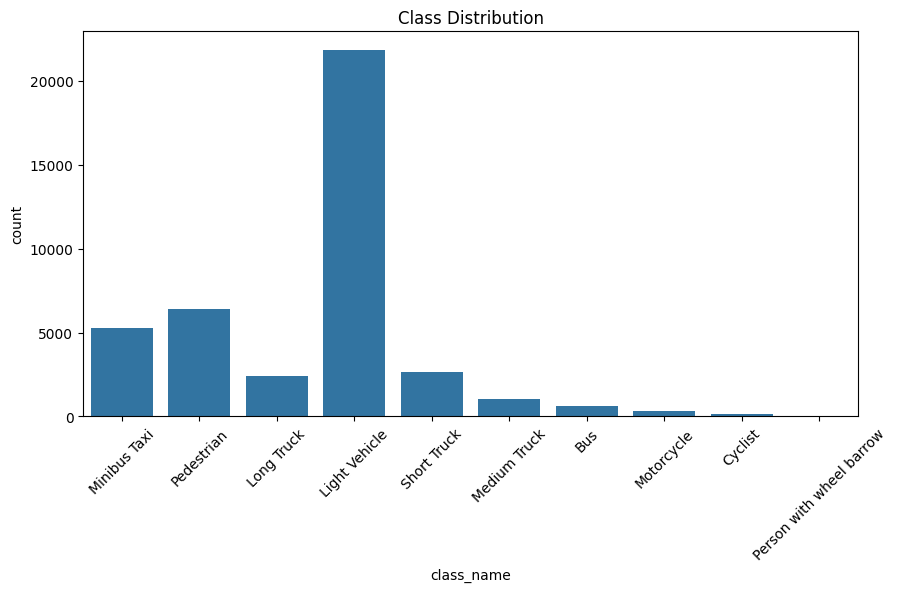

In [12]:
# استيراد مكتبات الرسم
import matplotlib.pyplot as plt
import seaborn as sns

# تحديد حجم الشكل (العرض 10، الارتفاع 5)
plt.figure(figsize=(10,5))

# رسم توزيع الكلاسات (عدد كل class في الداتا)
# x="class_name" → العمود اللي هنعدّ عليه
sns.countplot(data=df, x="class_name")

# عنوان الرسم
plt.title("Class Distribution")

# تدوير أسماء الكلاسات عشان تبقى مقروءة (لو طويلة)
plt.xticks(rotation=45)

# عرض الرسم
plt.show()

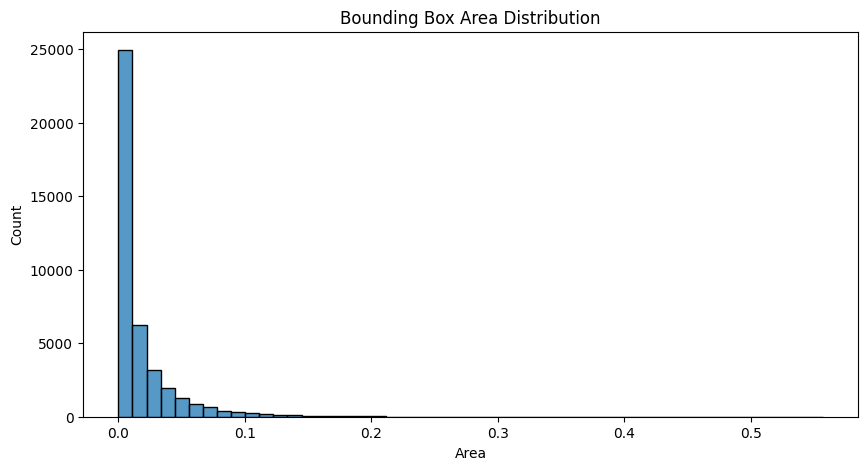

In [13]:
# تحديد حجم الشكل
plt.figure(figsize=(10,5))

# رسم توزيع قيم مساحة الـ bounding box
# df["bbox_area"] → العمود اللي فيه مساحة كل object
# bins=50 → تقسيم البيانات لـ 50 فئة (تفاصيل أدق في التوزيع)
sns.histplot(df["bbox_area"], bins=50)

# عنوان الرسم
plt.title("Bounding Box Area Distribution")

# اسم المحور X (المساحة)
plt.xlabel("Area")

# عرض الرسم
plt.show()

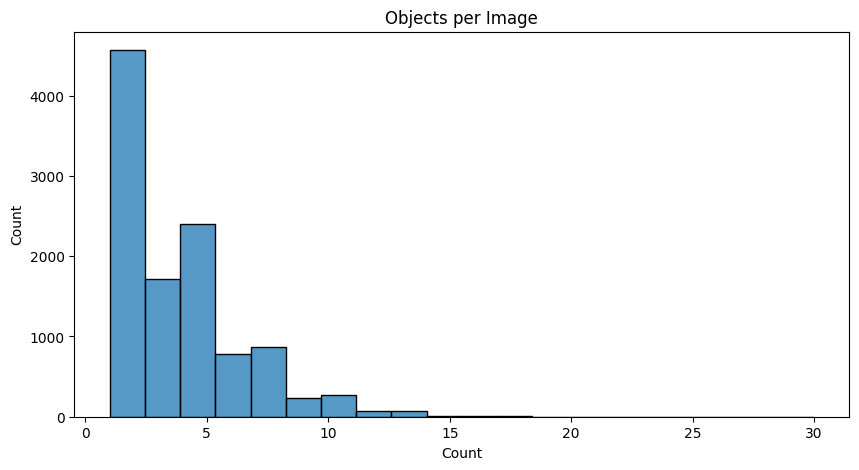

In [14]:
# حساب عدد الـ objects في كل صورة
# groupby("filename") → تجميع البيانات حسب اسم الصورة
# .size() → حساب عدد الـ rows (objects) في كل صورة
objects_per_image = df.groupby("filename").size()

# تحديد حجم الشكل
plt.figure(figsize=(10,5))

# رسم توزيع عدد الـ objects لكل صورة
# bins=20 → تقسيم القيم لـ 20 فئة
sns.histplot(objects_per_image, bins=20)

# عنوان الرسم
plt.title("Objects per Image")

# اسم المحور X (عدد الـ objects)
plt.xlabel("Count")

# عرض الرسم
plt.show()


Images found: 11005
Labels found: 11005


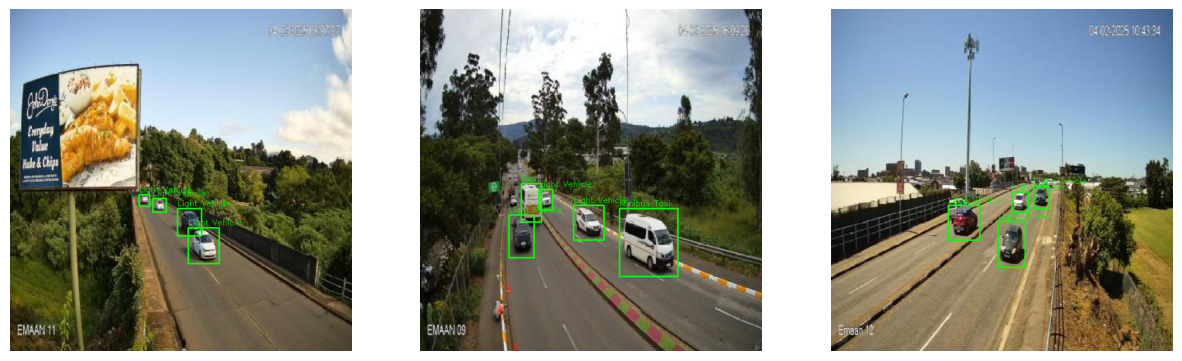

In [16]:
# استيراد مكتبة OpenCV للتعامل مع الصور
import cv2

# لاختيار صور عشوائية
import random

# للرسم
import matplotlib.pyplot as plt

# للتعامل مع المسارات
from pathlib import Path

# function لعرض عدد n من الصور مع الـ bounding boxes
def show_sample(image_dir, label_dir, class_names, n=3):

    # جلب كل الصور من فولدر الصور
    image_files = list(Path(image_dir).glob("*"))

    # حماية: لو عدد الصور أقل من المطلوب → ما يقعش
    if len(image_files) < n:
        print(f"❌ Error: Found only {len(image_files)} images in {image_dir}. Need at least {n}.")
        return

    # اختيار n صور عشوائيًا
    samples = random.sample(image_files, n)

    # إنشاء canvas للرسم
    fig, axes = plt.subplots(1, n, figsize=(15,5))

    # loop على الصور المختارة
    for ax, img_path in zip(axes, samples):

        # قراءة الصورة
        img = cv2.imread(str(img_path))

        # تحويلها من BGR (OpenCV) لـ RGB (Matplotlib)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # أبعاد الصورة
        h, w = img.shape[:2]

        # تحديد مسار ملف الـ label المقابل للصورة
        label_path = Path(label_dir) / (img_path.stem + ".txt")

        # لو فيه label للصورة
        if label_path.exists():
            with open(label_path) as f:
                for line in f:

                    # قراءة القيم (YOLO format: class x y w h)
                    cls, x, y, bw, bh = map(float, line.split())

                    # تحويل الإحداثيات من normalized → pixel
                    x1 = int((x - bw/2) * w)
                    y1 = int((y - bh/2) * h)
                    x2 = int((x + bw/2) * w)
                    y2 = int((y + bh/2) * h)

                    # رسم البوكس
                    cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

                    # كتابة اسم الكلاس
                    cv2.putText(img, class_names[int(cls)], (x1, y1-5),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

        # عرض الصورة
        ax.imshow(img)
        ax.axis("off")

    # عرض كل الصور
    plt.show()


# ==============================
# ✅ FIX: استخدام المسار الصح من Google Drive
# ==============================

# بدل /content/dataset/... اللي كان فاضي
LOCAL_TRAIN_IMAGES = f"{BASE_PATH}/train/images"
LOCAL_TRAIN_LABELS = f"{BASE_PATH}/train/labels"

# أسماء الكلاسات
OFFICIAL_CLASS_NAMES = [
    'Bus', 'Cyclist', 'Light Vehicle', 'Long Truck', 'Medium Truck',
    'Minibus Taxi', 'Motorcycle', 'Pedestrian', 'Person with wheel barrow', 'Short Truck'
]

# (اختياري لكن مهم) نتأكد إن فيه صور قبل ما نشغل
print("Images found:", len(list(Path(LOCAL_TRAIN_IMAGES).glob("*"))))
print("Labels found:", len(list(Path(LOCAL_TRAIN_LABELS).glob("*.txt"))))

# استدعاء الفنكشن
show_sample(LOCAL_TRAIN_IMAGES, LOCAL_TRAIN_LABELS, OFFICIAL_CLASS_NAMES)

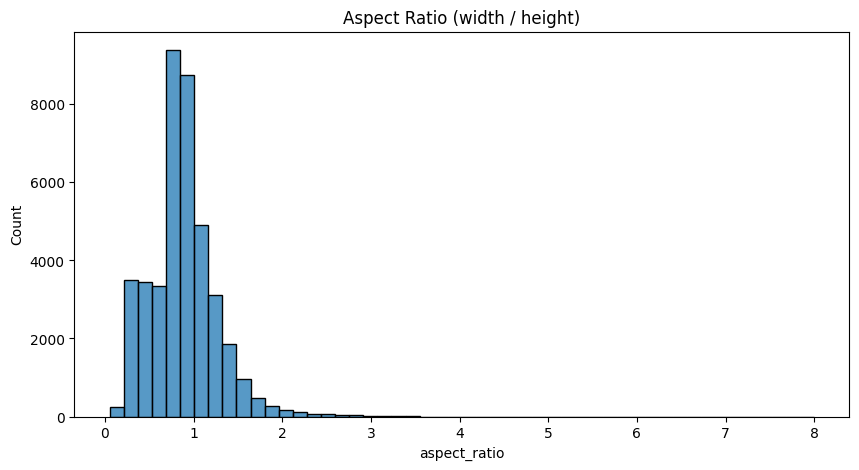

In [17]:
# إنشاء عمود جديد اسمه aspect_ratio (نسبة العرض إلى الارتفاع)
# width / height → بيقولك البوكس عريض ولا طويل
df["aspect_ratio"] = df["width"] / df["height"]

# استيراد مكتبات الرسم
import seaborn as sns
import matplotlib.pyplot as plt

# تحديد حجم الشكل
plt.figure(figsize=(10,5))

# رسم توزيع الـ aspect ratio
# bins=50 → تفاصيل أدق في التوزيع
sns.histplot(df["aspect_ratio"], bins=50)

# عنوان الرسم
plt.title("Aspect Ratio (width / height)")

# عرض الرسم
plt.show()

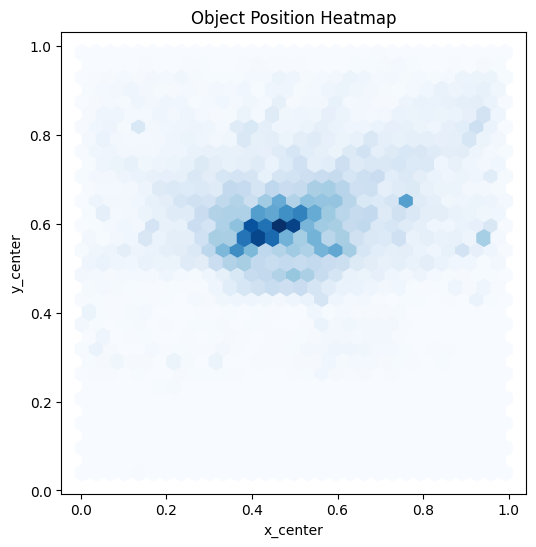

In [18]:
# تحديد حجم الشكل (مربع عشان يناسب توزيع الإحداثيات)
plt.figure(figsize=(6,6))

# رسم heatmap باستخدام hexbin لتوزيع مواقع الـ objects
# x_center و y_center → إحداثيات مركز الـ bounding box (normalized من 0 لـ 1)
# gridsize=30 → عدد الخلايا (كل ما زاد → تفاصيل أكتر)
# cmap="Blues" → لون التدرج
plt.hexbin(df["x_center"], df["y_center"], gridsize=30, cmap="Blues")

# عنوان الرسم
plt.title("Object Position Heatmap")

# تسمية المحاور
plt.xlabel("x_center")
plt.ylabel("y_center")

# عرض الرسم
plt.show()

In [19]:
# تحديد threshold لمساحة الـ bounding box
# أي object مساحته أقل من 0.01 نعتبره "small جدًا"
small_threshold = 0.01

# فلترة الداتا: نجيب بس الـ objects الصغيرة جدًا
small_objects = df[df["bbox_area"] < small_threshold]

# طباعة عددهم
print("Very small objects:", len(small_objects))

Very small objects: 23839


In [20]:
# اختيار عينة عشوائية من الـ small objects
# min(3, len(small_objects)) → لو عددهم أقل من 3 ياخد المتاح بس (عشان ما يعملش error)
sample = small_objects.sample(min(3, len(small_objects)))

# loop على كل صف في العينة
for _, row in sample.iterrows():

    # طباعة اسم الكلاس + مساحة الـ bounding box
    print(row["class_name"], row["bbox_area"])

Minibus Taxi 0.0045501708984375
Pedestrian 0.002947998046875
Light Vehicle 0.0010040283203125


In [21]:
print(os.listdir(f"{BASE_PATH}/train"))

['images', 'labels']


In [22]:
import os
import shutil
import random
from pathlib import Path

# المسار الأساسي على Google Drive
BASE_PATH = "/content/drive/MyDrive/vehicle dataset"

# الصور والـ labels الأصلية
TRAIN_IMAGES = f"{BASE_PATH}/train/images"
TRAIN_LABELS = f"{BASE_PATH}/train/labels"

# مكان حفظ الداتا بعد الـ split
OUTPUT_PATH = f"{BASE_PATH}/dataset"

# مسارات الإخراج
train_img_out = f"{OUTPUT_PATH}/train/images"
train_lbl_out = f"{OUTPUT_PATH}/train/labels"
val_img_out   = f"{OUTPUT_PATH}/val/images"
val_lbl_out   = f"{OUTPUT_PATH}/val/labels"

# إنشاء الفولدرات لو مش موجودة
for path in [train_img_out, train_lbl_out, val_img_out, val_lbl_out]:
    os.makedirs(path, exist_ok=True)

# قراءة كل الصور
image_files = list(Path(TRAIN_IMAGES).glob("*"))

# تأكد إن فيه صور
print("Total images found:", len(image_files))

# عمل shuffle عشوائي
random.shuffle(image_files)

# تقسيم 80% / 20%
split_ratio = 0.8
split_index = int(len(image_files) * split_ratio)

train_files = image_files[:split_index]
val_files   = image_files[split_index:]

# function لنسخ الصور والـ labels
def copy_files(files, img_dest, lbl_dest):
    for img_path in files:
        label_path = Path(TRAIN_LABELS) / (img_path.stem + ".txt")

        shutil.copy(img_path, img_dest)

        if label_path.exists():
            shutil.copy(label_path, lbl_dest)

# تنفيذ التقسيم
copy_files(train_files, train_img_out, train_lbl_out)
copy_files(val_files, val_img_out, val_lbl_out)

# طباعة النتيجة
print("Split Done ✅")
print("Train:", len(train_files))
print("Val:", len(val_files))

Total images found: 11005
Split Done ✅
Train: 8804
Val: 2201


In [23]:
import yaml

DATASET_PATH = f"{BASE_PATH}/dataset"

data_yaml = {
    'path': DATASET_PATH,
    'train': 'train/images',
    'val': 'val/images',
    'nc': len(OFFICIAL_CLASS_NAMES),
    'names': OFFICIAL_CLASS_NAMES
}

yaml_path = f"{DATASET_PATH}/data.yaml"

with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f)

print("data.yaml created ✅")

data.yaml created ✅


In [24]:
with open(yaml_path) as f:
    print(f.read())

names:
- Bus
- Cyclist
- Light Vehicle
- Long Truck
- Medium Truck
- Minibus Taxi
- Motorcycle
- Pedestrian
- Person with wheel barrow
- Short Truck
nc: 10
path: /content/drive/MyDrive/vehicle dataset/dataset
train: train/images
val: val/images



In [1]:
import torch
print("GPU Available:", torch.cuda.is_available())

GPU Available: True


In [2]:
# ربط Google Drive
from google.colab import drive
drive.mount('/content/drive')

# المسار الأساسي للداتا
BASE_PATH = "/content/drive/MyDrive/vehicle dataset"

Mounted at /content/drive


In [4]:
# تثبيت المكتبة
!pip install -q ultralytics

from ultralytics import YOLO

# تحميل موديل جاهز
model = YOLO("yolov8n.pt")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
import yaml

# المسار بتاع الداتا بعد الـ split
DATASET_PATH = f"{BASE_PATH}/dataset"

# تعريف محتوى الملف
data_yaml = {
    'path': DATASET_PATH,          # المسار الأساسي
    'train': 'train/images',       # صور التدريب
    'val': 'val/images',           # صور الفاليديشن

    'nc': 10,                      # عدد الكلاسات (عدّل لو مختلف)

    'names': [
        'Bus', 'Cyclist', 'Light Vehicle', 'Long Truck', 'Medium Truck',
        'Minibus Taxi', 'Motorcycle', 'Pedestrian',
        'Person with wheel barrow', 'Short Truck'
    ]
}

# حفظ الملف
yaml_path = f"{DATASET_PATH}/data.yaml"

with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f)

print("data.yaml created ✅")
print("Saved at:", yaml_path)

data.yaml created ✅
Saved at: /content/drive/MyDrive/vehicle dataset/dataset/data.yaml


In [7]:
import os
print(os.path.exists(f"{BASE_PATH}/dataset/data.yaml"))

True


In [8]:
model.train(
    data=f"{BASE_PATH}/dataset/data.yaml",
    epochs=5,
    imgsz=640,
    batch=16,
    device=0,
    name="vehicle_detection"
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/vehicle dataset/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=vehicle_detection-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

FileNotFoundError: [34m[1mval: [0mError loading data from /content/drive/MyDrive/vehicle dataset/dataset/val/images
See https://docs.ultralytics.com/datasets for dataset formatting guidance.

In [9]:
import os

print("Train images:", len(os.listdir(f"{BASE_PATH}/dataset/train/images")))
print("Val images:", len(os.listdir(f"{BASE_PATH}/dataset/val/images")))

Train images: 7774
Val images: 0


In [10]:
import shutil

shutil.rmtree(f"{BASE_PATH}/dataset", ignore_errors=True)

print("Old dataset removed ✅")

Old dataset removed ✅


In [11]:
# =========================================
# Clean Split (80/20) مع تأكيد إن فيه صور في val
# =========================================

import os
import shutil
import random
from pathlib import Path

BASE_PATH = "/content/drive/MyDrive/vehicle dataset"

SRC_IMG = f"{BASE_PATH}/train/images"
SRC_LBL = f"{BASE_PATH}/train/labels"
DST     = f"{BASE_PATH}/dataset"

train_img = f"{DST}/train/images"
train_lbl = f"{DST}/train/labels"
val_img   = f"{DST}/val/images"
val_lbl   = f"{DST}/val/labels"

# إنشاء الفولدرات
for p in [train_img, train_lbl, val_img, val_lbl]:
    os.makedirs(p, exist_ok=True)

# قراءة الصور (فلاتر الصيغ المدعومة فقط)
images = [f for f in Path(SRC_IMG).glob("*") if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
print("Total source images:", len(images))

# Shuffle
random.shuffle(images)

# Split 80/20
split = int(len(images) * 0.8)
train_files = images[:split]
val_files   = images[split:]

print("Planned -> Train:", len(train_files), "| Val:", len(val_files))

def copy_files(files, img_dst, lbl_dst):
    for i, img_path in enumerate(files, 1):
        # Copy image
        shutil.copy(str(img_path), str(Path(img_dst) / img_path.name))

        # Copy label لو موجود
        lbl_path = Path(SRC_LBL) / (img_path.stem + ".txt")
        if lbl_path.exists():
            shutil.copy(str(lbl_path), str(Path(lbl_dst) / lbl_path.name))

        # Progress بسيط كل 1000
        if i % 1000 == 0:
            print(f"Copied {i} files...")

print("\nCopying TRAIN...")
copy_files(train_files, train_img, train_lbl)

print("\nCopying VAL...")
copy_files(val_files, val_img, val_lbl)

print("\nSplit Done ✅")

# تحقق نهائي
print("Final Check:")
print("Train images:", len(os.listdir(train_img)))
print("Val images:", len(os.listdir(val_img)))

Total source images: 11005
Planned -> Train: 8804 | Val: 2201

Copying TRAIN...
Copied 1000 files...
Copied 2000 files...
Copied 3000 files...
Copied 4000 files...
Copied 5000 files...
Copied 6000 files...
Copied 7000 files...
Copied 8000 files...

Copying VAL...
Copied 1000 files...
Copied 2000 files...

Split Done ✅
Final Check:
Train images: 8804
Val images: 2201


In [12]:
import yaml

# المسار بعد الـ split
DATASET_PATH = f"{BASE_PATH}/dataset"

# تعريف الملف
data_yaml = {
    'path': DATASET_PATH,          # المسار الأساسي
    'train': 'train/images',       # صور التدريب
    'val': 'val/images',           # صور الفاليديشن

    'nc': 10,                      # عدد الكلاسات
    'names': [
        'Bus', 'Cyclist', 'Light Vehicle', 'Long Truck', 'Medium Truck',
        'Minibus Taxi', 'Motorcycle', 'Pedestrian',
        'Person with wheel barrow', 'Short Truck'
    ]
}

# حفظ الملف
yaml_path = f"{DATASET_PATH}/data.yaml"

with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f)

print("data.yaml created ✅")
print("Path:", yaml_path)

data.yaml created ✅
Path: /content/drive/MyDrive/vehicle dataset/dataset/data.yaml


In [13]:
import os
print(os.path.exists(f"{BASE_PATH}/dataset/data.yaml"))

True


In [14]:
from ultralytics import YOLO

# تحميل موديل جاهز
model = YOLO("yolov8n.pt")

# تدريب مبدئي
model.train(
    data=f"{BASE_PATH}/dataset/data.yaml",  # الداتا
    epochs=5,        # Test Run
    imgsz=640,
    batch=16,
    device=0,        # GPU
    name="vehicle_detection"
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/vehicle dataset/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=vehicle_detection-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f332d277230>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

In [ ]:
from ultralytics import YOLO

# تحميل موديل جاهز
model = YOLO("yolov8n.pt")

# تدريب مبدئي
model.train(
    data=f"{BASE_PATH}/dataset/data.yaml",  # الداتا
    epochs=20,        # Test Run
    imgsz=640,
    batch=16,
    device=0,        # GPU
    name="vehicle_detection"
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/vehicle dataset/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=vehicle_detection-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=